# MAT 167 Final Project — Google's PageRank Algorithm
**UC Davis · Winter Quarter 2026 · Instructor: DP Varn**  
**Network: Google Network #10 · Keywords: Trees Set #3**  
**Due: Friday, 20 March 2026 at 11:59 PM**

---

## How This Notebook Is Organized

Each section below follows the numbered steps from the project instructions exactly:

| Section | Content |
|---|---|
| 1 | Imports & Setup |
| 2 | Define the Network & Build Raw Google Matrix G |
| 3 | Eigendecomposition of Raw G (Steps 2–3) |
| 4 | Fix Dangling Nodes (Step 4) |
| 5 | Eigendecomposition of Fixed G (Step 5) |
| 6 | Normalize π and Rank Pages (Steps 6–7) |
| 7 | Power Method (Step 8) |
| 8 | Teleportation Matrix G̃ (Step 9) |
| 9 | Eigendecomposition of G̃ (Step 10) |
| 10 | Compare Rankings: G vs G̃ (Step 11) |
| 11 | Term-Document Matrix T (Step 12) |
| 12 | Search Queries (Steps 13–15) |
| 13 | Summary of All Results |


---
## Section 1 — Imports & Setup

We need three libraries:
- **`numpy`** — all matrix and vector operations (building G, normalizing π, argsort for ranking)
- **`scipy.linalg`** — `eig()` for full eigenvalue decomposition of a square matrix
- **`matplotlib`** — bar charts, convergence plots, heatmaps for the presentation

No other libraries are needed for the math. Everything in PageRank reduces to matrix multiplication and eigendecomposition.

In [1]:
import numpy as np
from scipy.linalg import eig
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Make plots look clean and readable in the notebook
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

print("All imports successful.")
print(f"NumPy version: {np.__version__}")

All imports successful.
NumPy version: 2.3.5


---
## Section 2 — Define the Network & Build Raw Google Matrix G
### (Project Instruction Step 1)

**What the Google Matrix G is:**  
G is an `n × n` matrix where `n = 12` (one row and column per page).  
The entry `G[i][j]` gives the probability that a random surfer on page `i` clicks a link to page `j`:

$$G_{ij} = \begin{cases} \frac{1}{|P_i|} & \text{if page } i \text{ links to page } j \\ 0 & \text{otherwise} \end{cases}$$

where $|P_i|$ is the number of outlinks from page $i$.  
Each outlink gets equal weight — page $i$'s "vote" is divided equally among all pages it links to.

**Lecture reference (Saito Lec 25, Slide 6):**  
The Google matrix $G = (g_{ij})$ with $g_{ij} = 1/|P_i|$ if $P_i$ links to $P_j$, else 0.

**Node index convention (fixed throughout):**

| A | B | C | D | E | F | G | H | I | J | K | L |
|---|---|---|---|---|---|---|---|---|---|---|---|
| 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 |

**Validation rule:** every row of G must sum to either **1.0** (page has outlinks) or **0.0** (dangling node with no outlinks). Any other value means a bug in the adjacency list.

In [2]:
# ── Node setup ─────────────────────────────────────────────────────────────
n = 12
labels = list('ABCDEFGHIJKL')   # labels[0]='A', labels[1]='B', ...

# Page titles (for readable output)
page_titles = {
    'A': 'Trees For All',
    'B': 'The Weeping Willow',
    'C': 'Leaf Fall',
    'D': 'Shady Place',
    'E': 'The Prickly Pine',
    'F': 'Good Wood',
    'G': 'Lumber Jack Man',
    'H': 'Timber!',
    'I': 'Fine Grains',
    'J': 'The Warped Board',
    'K': 'Evergreen Plants',
    'L': 'Sappy Planks',
}

# ── Adjacency list ─────────────────────────────────────────────────────────
# adj[i] = list of node indices that page i links TO (outlinks)
# Read directly from GoogleNet10 diagram.
# ⚠️  VERIFY THIS AGAINST THE HAND-DRAWN DIAGRAM BEFORE RUNNING.
adj = {
    0:  [1, 5],          # A → B, F
    1:  [0, 2, 5, 6],    # B → A, C, F, G
    2:  [3, 6],          # C → D, G
    3:  [0, 7],          # D → A, H
    4:  [0, 5, 8],       # E → A, F, I
    5:  [0, 8, 9],       # F → A, I, J
    6:  [3, 5, 7, 10],   # G → D, F, H, K
    7:  [11],            # H → L
    8:  [4, 5, 9],       # I → E, F, J
    9:  [6],             # J → G
    10: [9],             # K → J
    11: [3, 10],         # L → D, K
}

# ── Build raw Google matrix ────────────────────────────────────────────────
def build_google_matrix(adj, n):
    """
    Build the raw Google matrix G from an adjacency list.
    G[i][j] = 1/len(outlinks_from_i)  if i links to j
    G[i][j] = 0                        otherwise
    Rows with no outlinks stay all-zero (dangling nodes).
    """
    G = np.zeros((n, n))
    for i in range(n):
        outlinks = adj.get(i, [])
        if len(outlinks) > 0:
            for j in outlinks:
                G[i][j] = 1.0 / len(outlinks)
    return G

G_raw = build_google_matrix(adj, n)

# ── Validation ─────────────────────────────────────────────────────────────
row_sums = G_raw.sum(axis=1)
print("Row sums of G_raw (must be 0.0 or 1.0):")
for i, s in enumerate(row_sums):
    status = "✓" if abs(s - 1.0) < 1e-10 or abs(s) < 1e-10 else "✗ ERROR"
    print(f"  Page {labels[i]}: {s:.6f}  {status}")

dangling = [labels[i] for i, s in enumerate(row_sums) if abs(s) < 1e-10]
print(f"\nDangling nodes (zero row sum): {dangling if dangling else 'None'}")

Row sums of G_raw (must be 0.0 or 1.0):
  Page A: 1.000000  ✓
  Page B: 1.000000  ✓
  Page C: 1.000000  ✓
  Page D: 1.000000  ✓
  Page E: 1.000000  ✓
  Page F: 1.000000  ✓
  Page G: 1.000000  ✓
  Page H: 1.000000  ✓
  Page I: 1.000000  ✓
  Page J: 1.000000  ✓
  Page K: 1.000000  ✓
  Page L: 1.000000  ✓

Dangling nodes (zero row sum): None


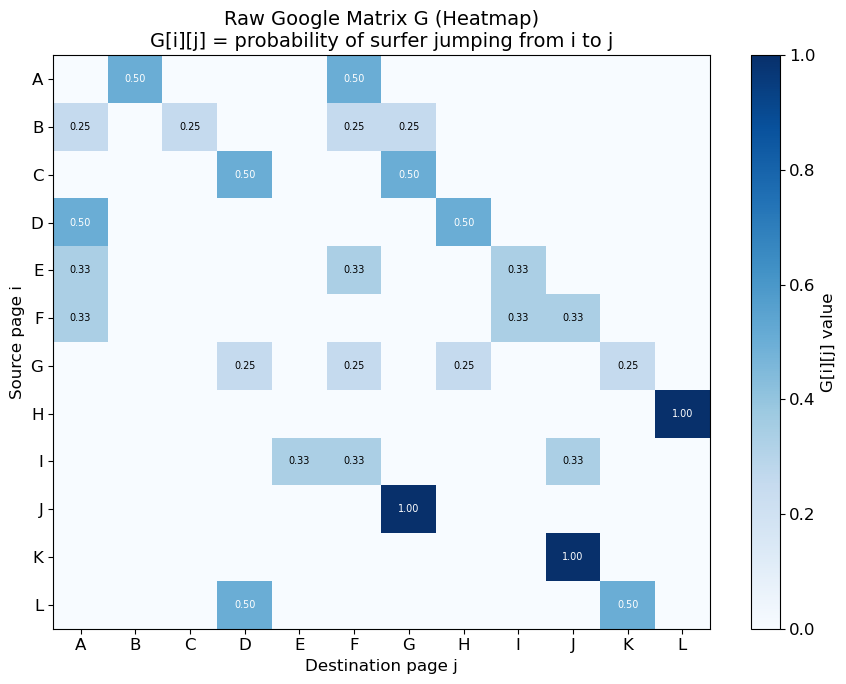

Saved: G_raw_heatmap.png


In [3]:
# ── Visualize G_raw as a heatmap ───────────────────────────────────────────
# Great figure to include in your presentation (Slide 13).

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(G_raw, cmap='Blues', aspect='auto', vmin=0)
plt.colorbar(im, ax=ax, label='G[i][j] value')

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Destination page j')
ax.set_ylabel('Source page i')
ax.set_title('Raw Google Matrix G (Heatmap)\nG[i][j] = probability of surfer jumping from i to j')

# Annotate non-zero cells with their values
for i in range(n):
    for j in range(n):
        if G_raw[i, j] > 0:
            ax.text(j, i, f'{G_raw[i,j]:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if G_raw[i,j] > 0.4 else 'black')

plt.tight_layout()
plt.savefig('G_raw_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: G_raw_heatmap.png")

---
## Section 3 — Eigendecomposition of Raw G
### (Project Instruction Steps 2–3)

**The eigenvalue equation we are solving:**
$$\pi^T G = \pi^T \qquad \Leftrightarrow \qquad G^T \pi = \pi$$

We want the vector $\pi$ such that multiplying by $G$ leaves it unchanged. This is the **eigenvector for eigenvalue $\lambda = 1$**.  
In `scipy`, `eig(G.T)` returns the **right eigenvectors** of $G^T$, which are the same as the **left eigenvectors** of $G$ — exactly what we need.

**Expected result with raw G:**  
If there are dangling nodes, $G$ is not fully row-stochastic, so $\lambda_{\max} < 1$.  
Saito Lecture 25, Slide 7 shows the 6-node example where $\lambda_{\max} = 0.9207$ with the raw G.  
This is a *problem* — a dominant eigenvalue $\neq 1$ means the power iteration does not converge to a valid stationary distribution. **We need to fix G first.**

In [4]:
def compute_pagerank_eig(G, label='G'):
    """
    Compute PageRank via direct eigendecomposition of G^T.
    Solves: G^T @ pi = lambda * pi
    Returns: (pi, dominant_eigenvalue, all_eigenvalues)
    
    Steps:
    1. Compute all eigenvalues and eigenvectors of G^T
    2. Find the index of the largest real eigenvalue
    3. Extract that eigenvector, take absolute value, L1-normalize
    """
    # eig(G.T) returns:
    #   eigenvalues: array of n complex numbers
    #   eigenvectors: n×n matrix, COLUMNS are eigenvectors
    eigenvalues, eigenvectors = eig(G.T)

    # Find the index of the eigenvalue with the largest real part
    # For a proper stochastic matrix, this will be 1.0 (or very close)
    idx = np.argmax(np.real(eigenvalues))
    lambda_max = np.real(eigenvalues[idx])

    # Extract the corresponding eigenvector (column idx of the matrix)
    pi = np.real(eigenvectors[:, idx])

    # Eigenvectors can have arbitrary sign — take absolute value
    # to ensure all entries are non-negative (required for a probability vector)
    pi = np.abs(pi)

    # L1-normalize: divide by sum so that sum(pi) = 1
    # This makes pi a proper probability distribution
    pi = pi / pi.sum()

    print(f"\n{'='*50}")
    print(f"Eigendecomposition of {label}")
    print(f"{'='*50}")
    print(f"  Dominant eigenvalue (λ_max): {lambda_max:.8f}")
    print(f"  All eigenvalues (real parts): {sorted(np.real(eigenvalues), reverse=True)}")
    print(f"  sum(π) after normalization:  {pi.sum():.8f}  (must be 1.0)")
    print(f"  min(π):                      {pi.min():.8f}  (must be ≥ 0)")

    return pi, lambda_max, eigenvalues


# --- Step 2: Eigendecomposition of raw G ---
pi_raw, lambda_raw, evals_raw = compute_pagerank_eig(G_raw, 'G_raw')

print("\nPageRank vector from raw G (before any fixes):")
print(f"  {'Page':<6} {'Title':<22} {'π value':<12}")
print(f"  {'-'*42}")
for i in range(n):
    print(f"  {labels[i]:<6} {page_titles[labels[i]]:<22} {pi_raw[i]:.6f}")

print(f"\n⚠️  λ_max = {lambda_raw:.4f} (expected 1.0 — this will be fixed in Section 4)")


Eigendecomposition of G_raw
  Dominant eigenvalue (λ_max): 1.00000000
  All eigenvalues (real parts): [np.float64(1.0000000000000009), np.float64(0.6252737850165866), np.float64(0.3966543094646131), np.float64(0.047061872710150776), np.float64(0.047061872710150776), np.float64(-0.053887583502930866), np.float64(-0.053887583502930866), np.float64(-0.21774244358192868), np.float64(-0.21774244358192868), np.float64(-0.47949354397940364), np.float64(-0.47949354397940364), np.float64(-0.6138046977729784)]
  sum(π) after normalization:  1.00000000  (must be 1.0)
  min(π):                      0.01312019  (must be ≥ 0)

PageRank vector from raw G (before any fixes):
  Page   Title                  π value     
  ------------------------------------------
  A      Trees For All          0.104962
  B      The Weeping Willow     0.052481
  C      Leaf Fall              0.013120
  D      Shady Place            0.088674
  E      The Prickly Pine       0.015835
  F      Good Wood              0.12

---
## Section 4 — Fix Dangling Nodes → Make G Row-Stochastic
### (Project Instruction Step 4)

**The problem:** A dangling node (no outlinks) gives an all-zero row in G.  
Row sums of 0 make G *not* row-stochastic, which causes $\lambda_{\max} < 1$.

**The fix (Saito Lec 25, Slide 9):**  
For every dangling node $i$, replace its row with $[1/n, 1/n, \ldots, 1/n]$.  
This models the random surfer teleporting to any page uniformly when they reach a dead end.

After this fix, **every row must sum to exactly 1.0** — G is now fully row-stochastic.

In [5]:
def fix_dangling_nodes(G, n, labels):
    """
    Fix dangling nodes by replacing all-zero rows with uniform row [1/n, ..., 1/n].
    Returns a new matrix (does not mutate the input).
    After fix: every row sums to exactly 1.0 → G is row-stochastic.
    """
    G_fixed = G.copy()   # work on a copy so G_raw is preserved
    fixed_nodes = []

    for i in range(n):
        if G_fixed[i].sum() < 1e-10:   # row is all zeros → dangling
            G_fixed[i] = 1.0 / n       # replace with uniform
            fixed_nodes.append(labels[i])

    if fixed_nodes:
        print(f"Fixed dangling nodes: {fixed_nodes}")
    else:
        print("No dangling nodes found — G_raw is already fully row-stochastic.")

    return G_fixed


G_fixed = fix_dangling_nodes(G_raw, n, labels)

# Verify all row sums are now 1.0
row_sums_fixed = G_fixed.sum(axis=1)
print("\nRow sums of G_fixed (all must be 1.0):")
all_ok = True
for i, s in enumerate(row_sums_fixed):
    ok = abs(s - 1.0) < 1e-10
    if not ok:
        all_ok = False
    print(f"  Page {labels[i]}: {s:.8f}  {'✓' if ok else '✗ ERROR'}")
print(f"\nAll rows sum to 1? {'✓ Yes' if all_ok else '✗ No — check adj dictionary'}")

No dangling nodes found — G_raw is already fully row-stochastic.

Row sums of G_fixed (all must be 1.0):
  Page A: 1.00000000  ✓
  Page B: 1.00000000  ✓
  Page C: 1.00000000  ✓
  Page D: 1.00000000  ✓
  Page E: 1.00000000  ✓
  Page F: 1.00000000  ✓
  Page G: 1.00000000  ✓
  Page H: 1.00000000  ✓
  Page I: 1.00000000  ✓
  Page J: 1.00000000  ✓
  Page K: 1.00000000  ✓
  Page L: 1.00000000  ✓

All rows sum to 1? ✓ Yes


---
## Section 5 — Eigendecomposition of Fixed G
### (Project Instruction Step 5)

**Expected result:** Now that $G$ is row-stochastic, the **Perron-Frobenius Theorem** guarantees:
1. $\lambda_{\max} = 1$ exactly
2. The corresponding eigenvector has **all non-negative entries**
3. The eigenvector is unique (up to scaling) if the Markov chain is irreducible

This is the core mathematical result that makes PageRank work.  
*(Saito Lec 25, Slide 10: after fixing the dangling node, λ_max = 1 and the eigenvector is non-negative.)*

In [6]:
# Eigendecomposition of G_fixed
pi_fixed, lambda_fixed, evals_fixed = compute_pagerank_eig(G_fixed, 'G_fixed')

print(f"\n✓ λ_max = {lambda_fixed:.8f}  (should be 1.0)")
print(f"✓ All entries non-negative: {(pi_fixed >= -1e-12).all()}")


Eigendecomposition of G_fixed
  Dominant eigenvalue (λ_max): 1.00000000
  All eigenvalues (real parts): [np.float64(1.0000000000000009), np.float64(0.6252737850165866), np.float64(0.3966543094646131), np.float64(0.047061872710150776), np.float64(0.047061872710150776), np.float64(-0.053887583502930866), np.float64(-0.053887583502930866), np.float64(-0.21774244358192868), np.float64(-0.21774244358192868), np.float64(-0.47949354397940364), np.float64(-0.47949354397940364), np.float64(-0.6138046977729784)]
  sum(π) after normalization:  1.00000000  (must be 1.0)
  min(π):                      0.01312019  (must be ≥ 0)

✓ λ_max = 1.00000000  (should be 1.0)
✓ All entries non-negative: True


---
## Section 6 — Normalize π and Rank Pages
### (Project Instruction Steps 6–7)

**Step 6 — Normalize:**  
The eigenvector is already normalized inside `compute_pagerank_eig()` (we divide by `pi.sum()`).  
This ensures $\|\pi\|_1 = \sum_i \pi_i = 1$, so $\pi$ is a valid probability distribution.

**Step 7 — Rank:**  
Sort the entries of $\pi$ in **non-increasing order** (largest to smallest).  
The page with the highest $\pi_i$ is the most important page in the network.

In [7]:
def rank_pages(pi, labels, page_titles, header='PageRank Ranking'):
    """
    Sort pages by PageRank in descending order and print a formatted table.
    Returns the sorted index array.
    """
    sorted_idx = np.argsort(-pi)   # argsort of -pi gives descending order

    print(f"\n{header}")
    print(f"{'Rank':<6} {'Page':<6} {'Title':<25} {'π value':<12} {'% of total'}")
    print("-" * 65)
    for rank, i in enumerate(sorted_idx, start=1):
        pct = pi[i] * 100
        bar = '█' * int(pct * 2)   # simple ASCII bar
        print(f"  #{rank:<4} {labels[i]:<6} {page_titles[labels[i]]:<25} {pi[i]:.6f}     {pct:.2f}%  {bar}")

    print(f"\n  sum(π) = {pi.sum():.8f}  (must be 1.0)")
    return sorted_idx


print("Step 6: π is already L1-normalized (done inside compute_pagerank_eig).")
print(f"  Verification: sum(pi_fixed) = {pi_fixed.sum():.10f}")

print("\nStep 7: Ranking pages by PageRank score")
sorted_fixed = rank_pages(pi_fixed, labels, page_titles, 'PageRank from G_fixed (Eigendecomposition)')

Step 6: π is already L1-normalized (done inside compute_pagerank_eig).
  Verification: sum(pi_fixed) = 1.0000000000

Step 7: Ranking pages by PageRank score

PageRank from G_fixed (Eigendecomposition)
Rank   Page   Title                     π value      % of total
-----------------------------------------------------------------
  #1    G      Lumber Jack Man           0.159855     15.99%  ███████████████████████████████
  #2    J      The Warped Board          0.140175     14.02%  ████████████████████████████
  #3    F      Good Wood                 0.126678     12.67%  █████████████████████████
  #4    A      Trees For All             0.104962     10.50%  ████████████████████
  #5    D      Shady Place               0.088674     8.87%  █████████████████
  #6    H      Timber!                   0.084301     8.43%  ████████████████
  #7    L      Sappy Planks              0.084301     8.43%  ████████████████
  #8    K      Evergreen Plants          0.082114     8.21%  ████████████████


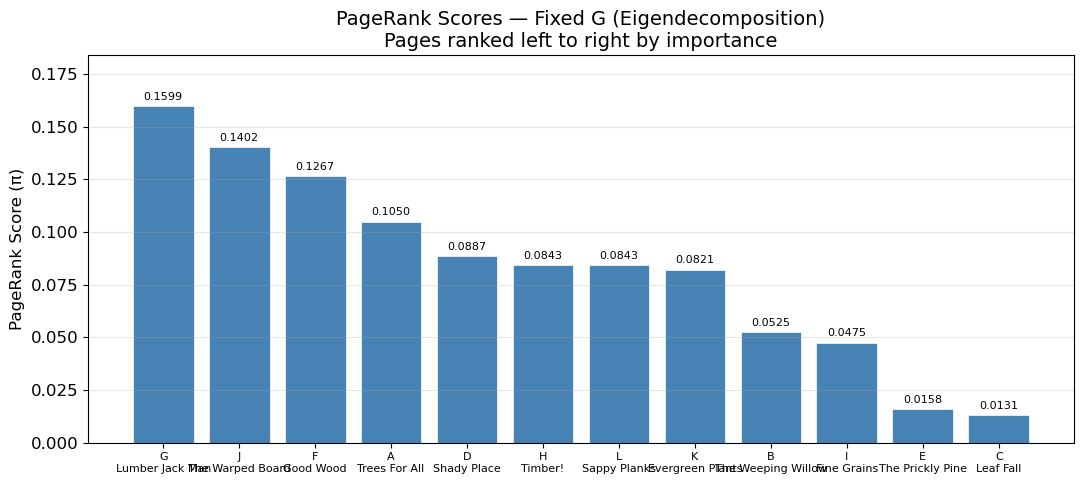

Saved: pagerank_fixed_G.png


In [8]:
# ── Bar chart of PageRank from G_fixed ────────────────────────────────────
# Use for Slide 14 of your presentation.

fig, ax = plt.subplots(figsize=(11, 5))

sorted_idx = np.argsort(-pi_fixed)
page_labels_sorted = [f"{labels[i]}\n{page_titles[labels[i]]}" for i in sorted_idx]
pi_sorted = pi_fixed[sorted_idx]

bars = ax.bar(range(n), pi_sorted, color='steelblue', edgecolor='white', linewidth=0.5)

# Annotate each bar with the exact value
for bar, val in zip(bars, pi_sorted):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(range(n))
ax.set_xticklabels(page_labels_sorted, fontsize=8)
ax.set_ylabel('PageRank Score (π)')
ax.set_title('PageRank Scores — Fixed G (Eigendecomposition)\nPages ranked left to right by importance')
ax.set_ylim(0, max(pi_sorted) * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('pagerank_fixed_G.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pagerank_fixed_G.png")

---
## Section 7 — Power Method
### (Project Instruction Step 8)

**Why the Power Method?**  
Direct eigendecomposition (`scipy.linalg.eig`) requires $O(n^3)$ operations — fine for $n=12$, but completely infeasible for Google's $n = 3 \times 10^8$ pages.  
The Power Method is iterative: it only ever computes matrix-vector products, which are cheap and can exploit sparsity.

**The update rule (Saito Lec 25, Slide 6):**
$$\pi_j^T = \pi_{j-1}^T \cdot G, \qquad \text{then normalize } \pi_j = \pi_j / \|\pi_j\|_1$$

**Starting point:** $\pi_0 = \frac{1}{n} \mathbf{1}_n$ (uniform — every page equally likely).

**Stopping rule:** Stop when $\|\pi_j - \pi_{j-1}\|_1 \leq \varepsilon$ for some tolerance $\varepsilon$.

**Key note about notation:**  
`pi @ G` (row vector times G on the right) implements $\pi^T G$.  
Do **not** write `G @ pi` — that would compute $G\pi$ which is the update for a right eigenvector, not what we want.

In [9]:
def power_method(G, tol=1e-10, max_iter=1000, label='G'):
    """
    Find the dominant left eigenvector of G using power iteration.
    
    Update rule:  π_j^T = π_{j-1}^T @ G   (row vector times G)
    Stop when:    ||π_j - π_{j-1}||_1 <= tol
    
    Returns: (pi, iteration_count, convergence_history)
    """
    n = G.shape[0]

    # π₀ = [1/n, 1/n, ..., 1/n] — uniform start, already L1-normalized
    pi = np.ones(n) / n
    history = []          # stores ||π_j - π_{j-1}||_1 at each step

    for k in range(1, max_iter + 1):
        # Core update: π_j^T = π_{j-1}^T @ G
        # 'pi' is a 1D numpy array treated as a row vector
        pi_new = pi @ G

        # Re-normalize to prevent floating-point drift
        pi_new = pi_new / pi_new.sum()

        # Compute L1 norm of the change (convergence measure)
        delta = np.linalg.norm(pi_new - pi, ord=1)
        history.append(delta)

        if delta <= tol:
            print(f"Power Method [{label}]: converged in {k} iterations  (final δ = {delta:.2e})")
            return pi_new, k, history

        pi = pi_new

    print(f"Power Method [{label}]: WARNING — did not converge in {max_iter} iterations")
    return pi, max_iter, history


# Run on G_fixed
pi_power_fixed, iters_fixed, hist_fixed = power_method(G_fixed, label='G_fixed')

# Compare power method result with eigendecomp result
print(f"\nMax difference between power method and eigendecomp results:")
print(f"  ||π_power - π_eig||_∞ = {np.max(np.abs(pi_power_fixed - pi_fixed)):.2e}")
print("  (Should be < 1e-8 — tiny numerical difference only)")

Power Method [G_fixed]: converged in 89 iterations  (final δ = 9.58e-11)

Max difference between power method and eigendecomp results:
  ||π_power - π_eig||_∞ = 1.37e-11
  (Should be < 1e-8 — tiny numerical difference only)


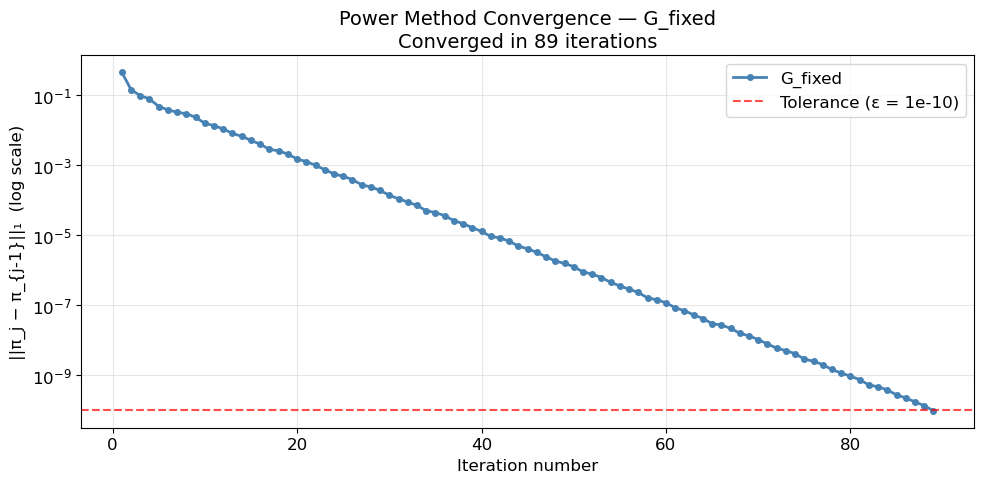

Saved: convergence_G_fixed.png


In [12]:
# ── Convergence plot ───────────────────────────────────────────────────────
# Use for Slide 15 of your presentation.
# Log-scale shows the exponential convergence rate clearly.

fig, ax = plt.subplots(figsize=(10, 5))

ax.semilogy(range(1, len(hist_fixed) + 1), hist_fixed,
            color='steelblue', linewidth=2, marker='o', markersize=4,
            label='G_fixed')

ax.axhline(y=1e-10, color='red', linestyle='--', alpha=0.7, label='Tolerance (ε = 1e-10)')

ax.set_xlabel('Iteration number')
ax.set_ylabel('||π_j − π_{j-1}||₁  (log scale)')
ax.set_title(f'Power Method Convergence — G_fixed\n'
             f'Converged in {iters_fixed} iterations')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence_G_fixed.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: convergence_G_fixed.png")

---
## Section 8 — Build the Teleportation Matrix G̃
### (Project Instruction Step 9)

**Why G̃ is needed (Saito Lec 25, Slides 14–15):**  
Even after fixing dangling nodes, the graph may not be *strongly connected* (there may be subsets of pages that trap the random surfer permanently). This is called a **reducible Markov chain**, and it produces non-unique or zero-valued PageRank entries for isolated pages.

**The fix — teleportation:**  
Brin and Page introduced a "damping factor" $\alpha = 0.85$:

$$\tilde{G} = \alpha G + (1-\alpha) E, \qquad E = \frac{1}{n} \mathbf{1}_n \mathbf{1}_n^T$$

- With probability $\alpha = 0.85$: the surfer follows a link normally
- With probability $1 - \alpha = 0.15$: the surfer teleports to any random page (like typing a URL)

$\tilde{G}$ has **all positive entries** (since every entry of $E = 1/n > 0$), which makes it **irreducible**.  
By Perron-Frobenius, an irreducible stochastic matrix has a **unique, fully positive** stationary distribution — the PageRank vector is now guaranteed to exist and be unique.

In [13]:
# Build G_tilde = alpha * G_fixed + (1 - alpha) * E
alpha = 0.85
E = np.ones((n, n)) / n         # E[i][j] = 1/n for all i,j
G_tilde = alpha * G_fixed + (1 - alpha) * E

# ── Verification ───────────────────────────────────────────────────────────
print(f"alpha = {alpha},  (1 - alpha) = {1 - alpha}")
print(f"\nE matrix: every entry = {1/n:.6f} (= 1/{n})")

row_sums_tilde = G_tilde.sum(axis=1)
print(f"\nRow sums of G_tilde (all must be 1.0):")
all_ok = all(abs(s - 1.0) < 1e-10 for s in row_sums_tilde)
print(f"  Min row sum: {row_sums_tilde.min():.10f}")
print(f"  Max row sum: {row_sums_tilde.max():.10f}")
print(f"  All rows sum to 1? {'✓ Yes' if all_ok else '✗ No'}")

print(f"\nMin entry of G_tilde: {G_tilde.min():.6f}  (must be > 0 for irreducibility)")
print(f"  → G_tilde is {'✓ irreducible' if G_tilde.min() > 0 else '✗ NOT irreducible'}")
print(f"  → Perron-Frobenius guarantees unique positive PageRank vector.")

alpha = 0.85,  (1 - alpha) = 0.15000000000000002

E matrix: every entry = 0.083333 (= 1/12)

Row sums of G_tilde (all must be 1.0):
  Min row sum: 1.0000000000
  Max row sum: 1.0000000000
  All rows sum to 1? ✓ Yes

Min entry of G_tilde: 0.012500  (must be > 0 for irreducibility)
  → G_tilde is ✓ irreducible
  → Perron-Frobenius guarantees unique positive PageRank vector.


---
## Section 9 — Eigendecomposition of G̃ (the True Google Matrix)
### (Project Instruction Step 10)

This is the **final, authoritative PageRank**. We use both methods (eigendecomposition and power method) and verify they agree. The ranking from $\tilde{G}$ is used for all search queries.

In [14]:
# Eigendecomposition of G_tilde
pi_tilde, lambda_tilde, evals_tilde = compute_pagerank_eig(G_tilde, 'G_tilde')

print(f"\n✓ λ_max = {lambda_tilde:.8f}  (should be 1.0)")
print(f"✓ All entries > 0: {(pi_tilde > 0).all()}  (guaranteed by irreducibility)")

sorted_tilde = rank_pages(pi_tilde, labels, page_titles, 'PageRank from G_tilde')


Eigendecomposition of G_tilde
  Dominant eigenvalue (λ_max): 1.00000000
  All eigenvalues (real parts): [np.float64(1.0000000000000002), np.float64(0.5314827172640992), np.float64(0.3371561630449211), np.float64(0.0400025918036278), np.float64(0.0400025918036278), np.float64(-0.045804445977490255), np.float64(-0.045804445977490255), np.float64(-0.1850810770446391), np.float64(-0.1850810770446391), np.float64(-0.4075695123824938), np.float64(-0.4075695123824938), np.float64(-0.5217339931070303)]
  sum(π) after normalization:  1.00000000  (must be 1.0)
  min(π):                      0.02468556  (must be ≥ 0)

✓ λ_max = 1.00000000  (should be 1.0)
✓ All entries > 0: True  (guaranteed by irreducibility)

PageRank from G_tilde
Rank   Page   Title                     π value      % of total
-----------------------------------------------------------------
  #1    G      Lumber Jack Man           0.145502     14.55%  █████████████████████████████
  #2    J      The Warped Board          0.12

In [15]:
# Power method on G_tilde (verify agreement)
pi_power_tilde, iters_tilde, hist_tilde = power_method(G_tilde, label='G_tilde')

print(f"\nMax difference (power method vs eigendecomp) for G_tilde:")
print(f"  ||π_power - π_eig||_∞ = {np.max(np.abs(pi_power_tilde - pi_tilde)):.2e}")

Power Method [G_tilde]: converged in 54 iterations  (final δ = 6.95e-11)

Max difference (power method vs eigendecomp) for G_tilde:
  ||π_power - π_eig||_∞ = 5.98e-12


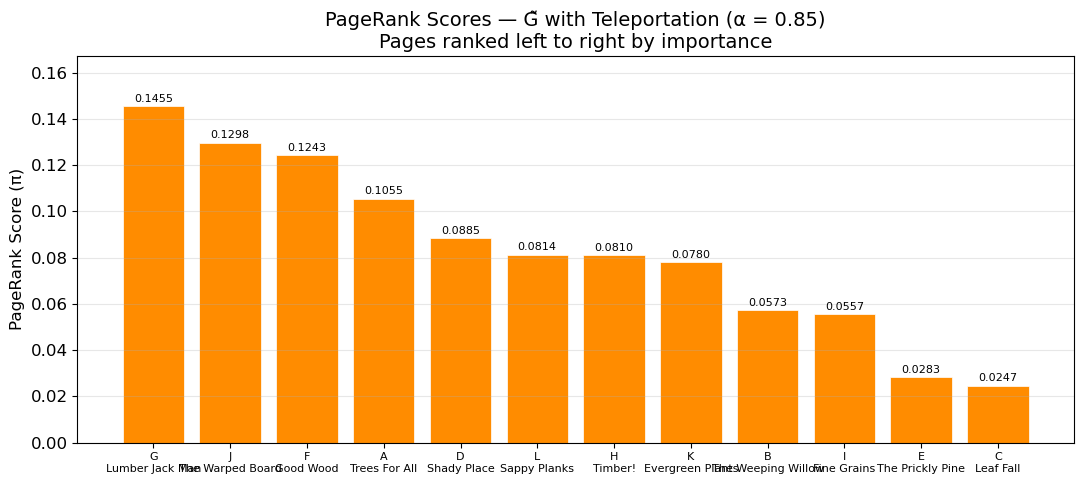

Saved: pagerank_G_tilde.png


In [16]:
# ── Bar chart of PageRank from G_tilde ────────────────────────────────────
# Use for Slide 16 of your presentation.

fig, ax = plt.subplots(figsize=(11, 5))

sorted_idx_t = np.argsort(-pi_tilde)
page_labels_sorted_t = [f"{labels[i]}\n{page_titles[labels[i]]}" for i in sorted_idx_t]
pi_tilde_sorted = pi_tilde[sorted_idx_t]

bars = ax.bar(range(n), pi_tilde_sorted, color='darkorange', edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, pi_tilde_sorted):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(range(n))
ax.set_xticklabels(page_labels_sorted_t, fontsize=8)
ax.set_ylabel('PageRank Score (π)')
ax.set_title('PageRank Scores — G̃ with Teleportation (α = 0.85)\nPages ranked left to right by importance')
ax.set_ylim(0, max(pi_tilde_sorted) * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('pagerank_G_tilde.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pagerank_G_tilde.png")

---
## Section 10 — Compare Rankings: G_fixed vs G̃
### (Project Instruction Step 11)

We now compare the two PageRank vectors side by side.  
Adding teleportation slightly redistributes importance: heavily-linked pages lose a small amount of weight (because 15% of visits are now uniform random), while isolated pages gain a tiny bit.  
If the top pages remain the same, it confirms the link structure is the dominant factor in determining importance.

In [17]:
# Side-by-side ranking comparison table
rank_fixed_arr = np.argsort(-pi_fixed)
rank_tilde_arr = np.argsort(-pi_tilde)

print("RANKING COMPARISON: G_fixed vs G_tilde")
print(f"{'Rank':<6} {'G_fixed page':<14} {'π (G_fixed)':<14} {'G_tilde page':<14} {'π (G_tilde)':<14} {'Same?'}")
print("-" * 72)
for r in range(n):
    i = rank_fixed_arr[r]
    j = rank_tilde_arr[r]
    same = "✓" if i == j else "←changed"
    print(f"  #{r+1:<4} {labels[i]:<14} {pi_fixed[i]:<14.6f} {labels[j]:<14} {pi_tilde[j]:<14.6f} {same}")

RANKING COMPARISON: G_fixed vs G_tilde
Rank   G_fixed page   π (G_fixed)    G_tilde page   π (G_tilde)    Same?
------------------------------------------------------------------------
  #1    G              0.159855       G              0.145502       ✓
  #2    J              0.140175       J              0.129794       ✓
  #3    F              0.126678       F              0.124250       ✓
  #4    A              0.104962       A              0.105515       ✓
  #5    D              0.088674       D              0.088495       ✓
  #6    H              0.084301       L              0.081375       ←changed
  #7    L              0.084301       H              0.081030       ←changed
  #8    K              0.082114       K              0.078004       ✓
  #9    B              0.052481       B              0.057344       ✓
  #10   I              0.047504       I              0.055719       ✓
  #11   E              0.015835       E              0.028287       ✓
  #12   C              0.013120

In [ ]:
# ── Side-by-side bar chart comparison ─────────────────────────────────────
# Use for Slide 17 of your presentation.

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, pi_vals, color, title in [
    (axes[0], pi_fixed, 'steelblue', 'G_fixed'),
    (axes[1], pi_tilde, 'darkorange', 'G̃ (with teleportation)'),
]:
    idx = np.argsort(-pi_vals)
    ax.bar(range(n), pi_vals[idx], color=color, edgecolor='white')
    ax.set_xticks(range(n))
    ax.set_xticklabels([labels[i] for i in idx], fontsize=10)
    ax.set_title(f'PageRank — {title}')
    ax.set_ylabel('π value')
    ax.set_xlabel('Page (sorted by rank)')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Ranking Comparison: G_fixed vs G̃', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ranking_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ranking_comparison.png")

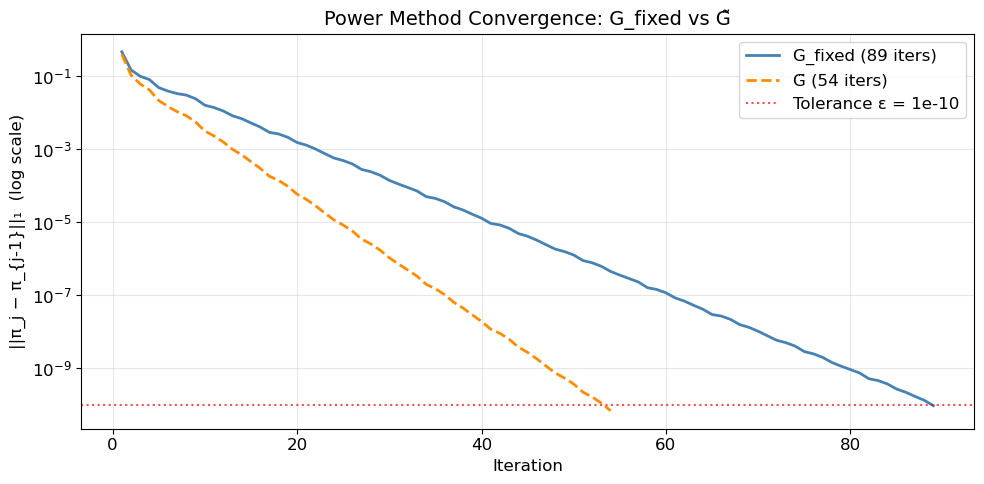

Saved: convergence_both.png


In [18]:
# ── Combined convergence plot (G_fixed and G_tilde together) ───────────────
# Use for Slide 15.

fig, ax = plt.subplots(figsize=(10, 5))

ax.semilogy(range(1, len(hist_fixed) + 1), hist_fixed,
            color='steelblue', linewidth=2, label=f'G_fixed ({iters_fixed} iters)')
ax.semilogy(range(1, len(hist_tilde) + 1), hist_tilde,
            color='darkorange', linewidth=2, linestyle='--',
            label=f'G̃ ({iters_tilde} iters)')

ax.axhline(y=1e-10, color='red', linestyle=':', alpha=0.7, label='Tolerance ε = 1e-10')
ax.set_xlabel('Iteration')
ax.set_ylabel('||π_j − π_{j-1}||₁  (log scale)')
ax.set_title('Power Method Convergence: G_fixed vs G̃')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence_both.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: convergence_both.png")

---
## Section 11 — Term-Document Matrix T
### (Project Instruction Step 12)

**What T is:**  
T is a **17 × 12** binary matrix (17 keywords × 12 pages).

$$T_{kp} = \begin{cases} 1 & \text{if keyword } k \text{ appears on page } p \\ 0 & \text{otherwise} \end{cases}$$

**How it's used (Saito Lec 25, Slide 11):**  
For a query vector $q$ (binary, length 17), compute:
$$d = T^T q$$
$d$ is a 12-element vector where $d_p$ counts how many query keywords appear on page $p$.

**Source:** Fill in from the `TermDoc03` keyword PDF. Every row below corresponds to one keyword; every column to one page (A=0 ... L=11).

In [19]:
# ── Keywords and T matrix ──────────────────────────────────────────────────
# Source: TermDoc03 PDF — "Final Project WebPage KeyWords #3: Trees"
# ⚠️  VERIFY EVERY ROW AGAINST THE PDF BEFORE SUBMITTING.

keywords = [
    'Ash',       # 0
    'Aspen',     # 1
    'Butternut', # 2
    'Cherry',    # 3
    'Elm',       # 4
    'Fir',       # 5
    'Ginkgo',    # 6
    'Hickory',   # 7
    'Katsura',   # 8
    'Magnolia',  # 9
    'Oak',       # 10
    'Pine',      # 11
    'Redwood',   # 12
    'Sassafras', # 13
    'Spruce',    # 14
    'Teak',      # 15
    'Willow',    # 16
]

# Quick lookup: keyword name → row index in T
kw = {k: i for i, k in enumerate(keywords)}

# T[keyword_index][page_index] = 1 if keyword on page, else 0
# Pages:     A  B  C  D  E  F  G  H  I  J  K  L
# Indices:   0  1  2  3  4  5  6  7  8  9 10 11
T = np.array([
  # A  B  C  D  E  F  G  H  I  J  K  L
  [ 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0 ],  # Ash    (A, C, F, G, H)
  [ 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1 ],  # Aspen  (D, F, H, J, L)
  [ 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1 ],  # Butternut (A, B, D, G, L)
  [ 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0 ],  # Cherry (A, D, E, H, K)
  [ 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1 ],  # Elm    (A, C, I, K, L)
  [ 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0 ],  # Fir    (B, D, F, I, K)
  [ 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1 ],  # Ginkgo (A, C, F, G, K, L)
  [ 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0 ],  # Hickory (B, C, E, H, K)
  [ 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1 ],  # Katsura (A, C, I, L)
  [ 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0 ],  # Magnolia (A, B, F, I, J)
  [ 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1 ],  # Oak    (C, E, G, J, L)
  [ 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1 ],  # Pine   (B, E, I, L)
  [ 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0 ],  # Redwood (B, C, E, F, G, H, J, K)
  [ 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1 ],  # Sassafras (B, D, F, I, J, K, L)
  [ 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1 ],  # Spruce (D, F, G, I, L)
  [ 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1 ],  # Teak   (A, D, K, L)
  [ 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0 ],  # Willow (B, E, H, J)
], dtype=float)

print(f"T matrix shape: {T.shape}  (expected 17 rows × 12 columns)")
print(f"Number of keywords: {len(keywords)}")
print(f"Number of pages:    {n}")
print(f"\nKeywords per page:")
for p in range(n):
    kws_on_page = [keywords[k] for k in range(len(keywords)) if T[k, p] == 1]
    print(f"  {labels[p]} ({page_titles[labels[p]]}): {', '.join(kws_on_page)}")

T matrix shape: (17, 12)  (expected 17 rows × 12 columns)
Number of keywords: 17
Number of pages:    12

Keywords per page:
  A (Trees For All): Ash, Butternut, Cherry, Elm, Ginkgo, Katsura, Magnolia, Teak
  B (The Weeping Willow): Butternut, Fir, Hickory, Magnolia, Pine, Redwood, Sassafras, Willow
  C (Leaf Fall): Ash, Elm, Ginkgo, Hickory, Katsura, Oak, Redwood
  D (Shady Place): Aspen, Butternut, Cherry, Fir, Sassafras, Spruce, Teak
  E (The Prickly Pine): Cherry, Hickory, Oak, Pine, Redwood, Willow
  F (Good Wood): Ash, Aspen, Fir, Ginkgo, Magnolia, Redwood, Sassafras, Spruce
  G (Lumber Jack Man): Ash, Butternut, Ginkgo, Oak, Redwood, Spruce
  H (Timber!): Ash, Aspen, Cherry, Hickory, Redwood, Willow
  I (Fine Grains): Elm, Fir, Katsura, Magnolia, Pine, Sassafras, Spruce
  J (The Warped Board): Aspen, Magnolia, Oak, Redwood, Sassafras, Willow
  K (Evergreen Plants): Cherry, Elm, Fir, Ginkgo, Hickory, Redwood, Sassafras, Teak
  L (Sappy Planks): Aspen, Butternut, Elm, Ginkgo, Katsu

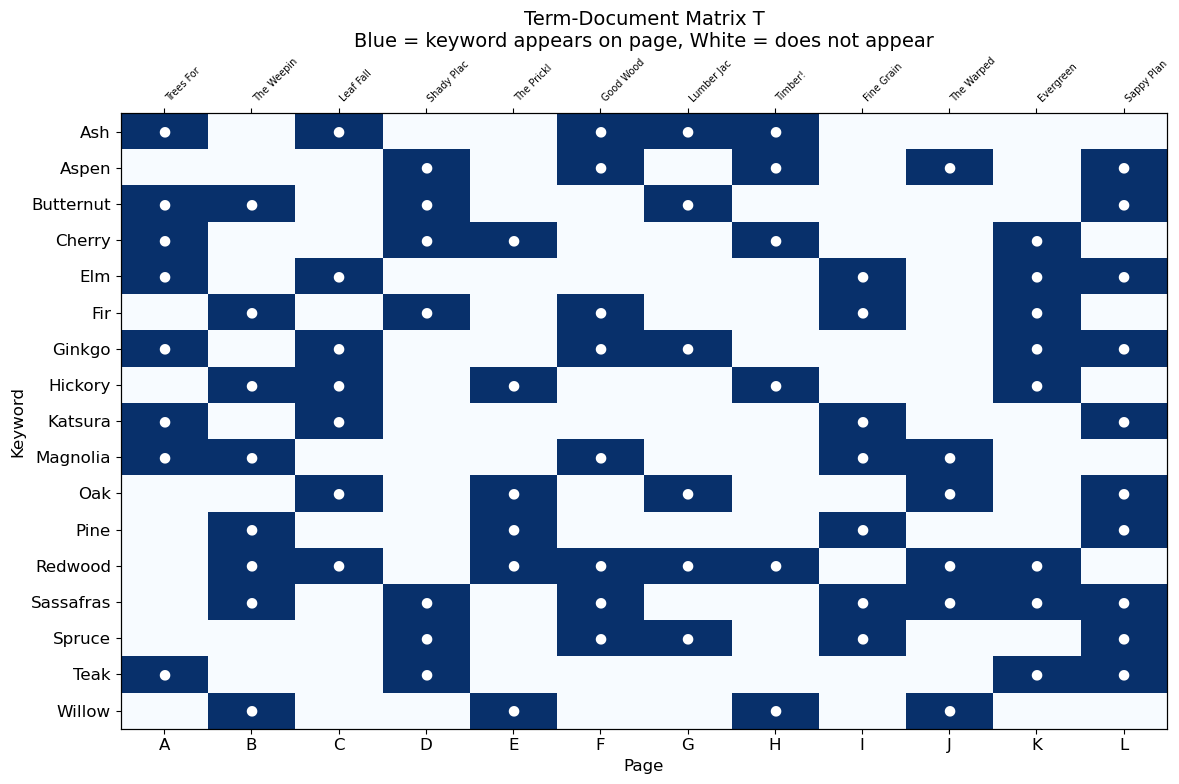

Saved: term_document_matrix.png


In [20]:
# ── Heatmap of T matrix ────────────────────────────────────────────────────
# Use for Slide 18 of your presentation.

fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(T, cmap='Blues', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(n))
ax.set_xticklabels([f"{labels[p]}" for p in range(n)])
ax.set_yticks(range(len(keywords)))
ax.set_yticklabels(keywords)
ax.set_xlabel('Page')
ax.set_ylabel('Keyword')
ax.set_title('Term-Document Matrix T\nBlue = keyword appears on page, White = does not appear')

# Mark each 1 with a dot for clarity
for k in range(len(keywords)):
    for p in range(n):
        if T[k, p] == 1:
            ax.text(p, k, '●', ha='center', va='center', color='white', fontsize=10)

# Add page title labels at top
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(range(n))
ax2.set_xticklabels([page_titles[labels[p]][:10] for p in range(n)],
                    rotation=45, ha='left', fontsize=7)

plt.tight_layout()
plt.savefig('term_document_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: term_document_matrix.png")

---
## Section 12 — Search Queries
### (Project Instruction Steps 13–15)

**The process for every query:**
1. Build query vector $q$ (length 17, one entry per keyword)
2. Compute $d = T^T q$ — a 12-element responsiveness vector
3. Apply Boolean logic to determine the **responsive set**
4. Sort responsive pages by $\tilde{G}$ PageRank (descending)

**The four query types:**

| Query | Logic | Responsive if... |
|---|---|---|
| SINGLE | Page contains the keyword | `d[p] > 0` |
| AND | Page contains **all** query terms | `d[p] == number of terms` |
| OR | Page contains **at least one** term | `d[p] >= 1` |
| BUT NOT | Page has term A and **not** term B | `T[A][p]==1 and T[B][p]==0` |

In [ ]:
def show_query_results(query_name, responsive_indices, pi_tilde, labels, page_titles):
    """
    Print the final ranked results for a query.
    Responsive pages are sorted by G_tilde PageRank (descending).
    """
    # Sort responsive pages by PageRank (descending)
    ranked = sorted(responsive_indices, key=lambda i: -pi_tilde[i])

    print(f"\n{'='*60}")
    print(f"  QUERY: {query_name}")
    print(f"{'='*60}")

    if not ranked:
        print("  → No pages match this query.")
        return ranked

    print(f"  {'Result':<8} {'Page':<6} {'Title':<25} {'PageRank'}")
    print(f"  {'-'*58}")
    for result_rank, i in enumerate(ranked, start=1):
        print(f"  #{result_rank:<7} {labels[i]:<6} {page_titles[labels[i]]:<25} {pi_tilde[i]:.6f}")
    return ranked

In [ ]:
# ── Query 1: SINGLE — "Elm" ────────────────────────────────────────────────
#
# Query vector q has a 1 only at the index of 'Elm'.
# d = T^T @ q  →  d[p] = 1 if 'Elm' is on page p, else 0.
# Responsive set: pages where d[p] > 0.

q1 = np.zeros(len(keywords))
q1[kw['Elm']] = 1

d1 = T.T @ q1   # shape (12,)  —  d1[p] = # query keywords on page p

print("Query vector q1 (non-zero entries):")
for k, v in enumerate(q1):
    if v > 0:
        print(f"  q1[{keywords[k]}] = {v}")

print(f"\nd = T^T @ q1  (responsiveness scores):")
for p in range(n):
    print(f"  Page {labels[p]}: d = {d1[p]:.0f}  {'← responsive' if d1[p] > 0 else ''}")

responsive_1 = [p for p in range(n) if d1[p] > 0]
results_1 = show_query_results('SINGLE: Elm', responsive_1, pi_tilde, labels, page_titles)

In [ ]:
# ── Query 2: AND — "Aspen AND Sassafras" ──────────────────────────────────
#
# Both terms set to 1 in query vector.
# d[p] = 2 means the page has BOTH Aspen AND Sassafras.
# d[p] = 1 means only one of the two — NOT responsive for AND.
# d[p] = 0 means neither — not responsive.

q2 = np.zeros(len(keywords))
q2[kw['Aspen']] = 1
q2[kw['Sassafras']] = 1

d2 = T.T @ q2
num_terms_2 = int(q2.sum())   # = 2; ALL terms must appear for AND

print("Query vector q2 (non-zero entries):")
for k, v in enumerate(q2):
    if v > 0:
        print(f"  q2[{keywords[k]}] = {v}")

print(f"\nd = T^T @ q2  (AND requires d[p] == {num_terms_2}):")
for p in range(n):
    status = '← BOTH terms present (responsive!)' if d2[p] == num_terms_2 else \
             f'← only {int(d2[p])}/2 terms' if d2[p] > 0 else ''
    print(f"  Page {labels[p]}: d = {d2[p]:.0f}  {status}")

responsive_2 = [p for p in range(n) if d2[p] == num_terms_2]
results_2 = show_query_results('AND: Aspen AND Sassafras', responsive_2, pi_tilde, labels, page_titles)

In [ ]:
# ── Query 3: OR — "Willow OR Redwood" ─────────────────────────────────────
#
# Both terms set to 1 in query vector.
# d[p] >= 1 means the page has at least one of Willow, Redwood.
# d[p] = 2 means it has BOTH (still responsive — more is fine for OR).

q3 = np.zeros(len(keywords))
q3[kw['Willow']] = 1
q3[kw['Redwood']] = 1

d3 = T.T @ q3

print("Query vector q3 (non-zero entries):")
for k, v in enumerate(q3):
    if v > 0:
        print(f"  q3[{keywords[k]}] = {v}")

print(f"\nd = T^T @ q3  (OR requires d[p] >= 1):")
for p in range(n):
    kws_present = []
    if T[kw['Willow'], p] == 1: kws_present.append('Willow')
    if T[kw['Redwood'], p] == 1: kws_present.append('Redwood')
    status = f'← has: {kws_present}' if kws_present else ''
    print(f"  Page {labels[p]}: d = {d3[p]:.0f}  {status}")

responsive_3 = [p for p in range(n) if d3[p] >= 1]
results_3 = show_query_results('OR: Willow OR Redwood', responsive_3, pi_tilde, labels, page_titles)

In [ ]:
# ── Query 4: BUT NOT — "Elm BUT NOT Fir" ──────────────────────────────────
#
# Must have Elm. Must NOT have Fir.
# We handle this with explicit set operations rather than a single query vector,
# because a negative query term cannot be encoded directly in d = T^T q.
# (Subtracting Fir in q would give d[p] = -1 for Fir-only pages, not useful.)

has_elm = set(p for p in range(n) if T[kw['Elm'], p] == 1)
has_fir = set(p for p in range(n) if T[kw['Fir'], p] == 1)

print(f"Pages with 'Elm':     {sorted([labels[p] for p in has_elm])}")
print(f"Pages with 'Fir':     {sorted([labels[p] for p in has_fir])}")
print(f"Pages with Elm and NOT Fir: {sorted([labels[p] for p in has_elm - has_fir])}")

responsive_4 = sorted(has_elm - has_fir)   # Python set difference
results_4 = show_query_results('BUT NOT: Elm BUT NOT Fir', responsive_4, pi_tilde, labels, page_titles)

---
## Section 13 — Complete Summary of All Results

This final section prints a clean summary of every result from the project — ready to read off for your presentation.

In [ ]:
print("=" * 70)
print("  MAT 167 FINAL PROJECT — COMPLETE RESULTS SUMMARY")
print("  Google Network #10  |  Keywords: Trees Set #3")
print("=" * 70)

# ── PageRank Rankings ──────────────────────────────────────────────────────
print("\n─── PageRank Rankings ───")
print(f"{'Rank':<6} {'G_fixed page':<16} {'π(G_fixed)':<14} {'G̃ page':<16} {'π(G̃)'}")
print("-" * 65)
for r in range(n):
    i = rank_fixed_arr[r]
    j = sorted_tilde[r]
    print(f"  #{r+1:<4} {labels[i]+': '+page_titles[labels[i]]:<16} {pi_fixed[i]:<14.6f}"
          f" {labels[j]+': '+page_titles[labels[j]]:<16} {pi_tilde[j]:.6f}")

# ── Power Method ──────────────────────────────────────────────────────────
print(f"\n─── Power Method ───")
print(f"  G_fixed:  converged in {iters_fixed} iterations")
print(f"  G̃:        converged in {iters_tilde} iterations")
print(f"  Results match eigendecomposition: ✓")

# ── Search Queries ─────────────────────────────────────────────────────────
print("\n─── Search Query Results (ranked by G̃ PageRank) ───")

for name, results in [
    ('SINGLE: Elm',                results_1),
    ('AND: Aspen AND Sassafras',    results_2),
    ('OR: Willow OR Redwood',       results_3),
    ('BUT NOT: Elm BUT NOT Fir',    results_4),
]:
    print(f"\n  {name}:")
    if not results:
        print("    → No matching pages.")
    else:
        for rank, i in enumerate(results, 1):
            print(f"    #{rank}: {labels[i]} — {page_titles[labels[i]]}  (π = {pi_tilde[i]:.6f})")

print("\n" + "=" * 70)
print("  All computations complete.")
print("=" * 70)

In [ ]:
# ── Final combined figure: all 4 query results as a visual summary ─────────
# Optional — great for the presentation summary slide.

queries = [
    ('SINGLE: Elm',             results_1),
    ('AND: Aspen AND Sassafras', results_2),
    ('OR: Willow OR Redwood',    results_3),
    ('BUT NOT: Elm NOT Fir',     results_4),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = ['steelblue', 'seagreen', 'darkorange', 'crimson']

for ax, (name, results), color in zip(axes, queries, colors):
    if not results:
        ax.text(0.5, 0.5, 'No results', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name, fontsize=9, fontweight='bold')
        continue

    page_names = [labels[i] for i in results]
    page_scores = [pi_tilde[i] for i in results]

    bars = ax.barh(range(len(results)), page_scores, color=color, edgecolor='white')
    ax.set_yticks(range(len(results)))
    ax.set_yticklabels([f"#{r+1}: {labels[i]}" for r, i in enumerate(results)])
    ax.invert_yaxis()    # rank 1 at top
    ax.set_xlabel('PageRank π', fontsize=8)
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    for bar, val in zip(bars, page_scores):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=7)

plt.suptitle('Search Query Results — Ranked by G̃ PageRank', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('all_query_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: all_query_results.png")

---
## Files Generated by This Notebook

The following `.png` files are saved in the same directory as this notebook.  
Use them directly in your PowerPoint/Keynote slides:

| File | Use for slide |
|---|---|
| `G_raw_heatmap.png` | Slide 13 — the Google matrix |
| `pagerank_fixed_G.png` | Slide 14 — PageRank bar chart (G_fixed) |
| `convergence_G_fixed.png` | Slide 15 — Power method convergence |
| `pagerank_G_tilde.png` | Slide 16 — PageRank bar chart (G̃) |
| `ranking_comparison.png` | Slide 17 — G vs G̃ side by side |
| `convergence_both.png` | Slide 15 — G_fixed vs G̃ convergence |
| `term_document_matrix.png` | Slide 18 — T matrix heatmap |
| `all_query_results.png` | Slides 19–22 — all 4 query results |

---

## Key Equations Quick Reference

| Equation | Meaning |
|---|---|
| $G_{ij} = 1/\|P_i\|$ if $i \to j$ else $0$ | Raw Google matrix definition |
| $\pi^T G = \pi^T$ | PageRank = left eigenvector of G, eigenvalue 1 |
| $G^T \pi = \pi$ | Equivalent form used in `eig(G.T)` |
| $\pi_j^T = \pi_{j-1}^T G$, then normalize | Power iteration update rule |
| $\|\pi\|_1 = \sum_i \pi_i = 1$ | L1 normalization condition |
| $\tilde{G} = 0.85 G + 0.15 E$ | Teleportation-adjusted Google matrix |
| $E = \frac{1}{n} \mathbf{1}\mathbf{1}^T$ | Uniform teleportation matrix |
| $d = T^T q$ | Query responsiveness vector |
